In [13]:
import numpy as np
import openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import os
import lr1b



## Implementation of the channel spectral sensitivity correction as reported in AN000633

Measured 3 miniPAR along with a spectrometer (LR1-B) and a PAR sensor (Licor Li-250A). The dataset is used to estimate the AS7341 channel sensitivity and then to do a linear regression to predict PAR. 
- §2.1 Calculate basic counts
- §2.2 remove default offset 
- Calculate the "real irradiance" of the LR1-B corrected by its exposure (ms) and calibration sensitivity response
- §2.4 calculate the AS7341 channel sensitivity

NB §2.3 not reported  since it is a situational fallback for unstable NIR without a matrix; the reconstruction matrix's negative lobes (e.g. F2 = −0.0339 and Clear = −0.0070 at 380 nm) already subtract the out-of-band leakage. Applying both would double-correct.



In [14]:
XLSX = '../Firmware/docs/AS7341_AD000198_3-00.xlsx'
DATA = "../data/"
CH = ['f1_415', 'f2_445', 'f3_480', 'f4_515', 'f5_555',
      'f6_590', 'f7_630', 'f8_680', 'clear', 'nir']

df = pd.read_csv(os.path.join(DATA, 'multi_par_spec_lr1b.csv'))
grid = np.loadtxt(os.path.join(DATA, 'lr1b_spectra', os.path.basename(p=df.lr1b_spectrum_file.iloc[0])))[:, 0]

print('rows %d | captures %d | devices %d | tags %d | PAR %.1f-%.1f'
      % (len(df), df.measurement.nunique(), df.miniPAR.nunique(),
         df.metadata.nunique(), df.tia_par.min(), df.tia_par.max()))


rows 195 | captures 65 | devices 3 | tags 14 | PAR 3.7-1900.6


In [15]:

# The .clbr is device-specific: assert it reproduces the data's own wavelength grid.
cal = lr1b.Calibration.from_file(os.path.join(DATA, 'N 3163.clbr'))
order = np.argsort(cal.wavelengths)          # device order is descending; files are ascending
assert len(cal.wavelengths) == len(grid), 'clbr has %d pixels, data has %d' % (len(cal.wavelengths), len(grid))
gap = float(np.max(np.abs(cal.wavelengths[order] - grid)))
assert gap < 1e-6, 'N 3163.clbr does not reproduce the data wavelength grid (%.4f nm)' % gap

irr_a, prnu_a = cal.irr_norm[order], cal.prnu_norm[order]
ok = irr_a > 0
print('cal serial %s | grid match %.1e nm | irradiance pixels %d/%d (%.1f-%.1f nm)'
      % (cal.serial, gap, ok.sum(), ok.size, grid[ok].min(), grid[ok].max()))


cal serial 3163 | grid match 0.0e+00 nm | irradiance pixels 3648/3648 (296.9-1017.5 nm)


## The published correction values

From sheet `used Correction Values`: the Golden-Device spectral reconstruction matrix (1 nm,
380–1100 nm, one column per channel) and the example offset vector.

In [16]:
ws = openpyxl.load_workbook(XLSX, data_only=True)['used Correction Values']
rows = []
for r in range(6, ws.max_row + 1):
    v = [ws.cell(r, c).value for c in range(1, 12)]          # A = WV, B..K = F1..NIR
    if all(isinstance(x, (int, float)) for x in v):
        rows.append(v)
cm = np.array(rows, float)
cm_wv, CM = cm[:, 0], cm[:, 1:]                              # (721,), (721, 10)
assert CM.shape[1] == len(CH)
print('CM %s, %g-%g nm, step %g nm' % (CM.shape, cm_wv.min(), cm_wv.max(), cm_wv[1] - cm_wv[0]))

# Workbook 'Offset, measured with sensor' (row 15, cols O..X) — ams units, i.e. t_int in ms.
OFFSET_BASIC = np.array([ws.cell(15, c).value for c in range(15, 25)], float)
print('offset vector (ams units):', np.array2string(OFFSET_BASIC, precision=6))
print('  -> in miniPAR basic counts (x1000):',
      np.array2string(OFFSET_BASIC * 1000, precision=2))

CM (721, 10), 380-1100 nm, step 1 nm
offset vector (ams units): [0.00197  0.007249 0.003194 0.001315 0.001468 0.001858 0.001763 0.005217
 0.003    0.001   ]
  -> in miniPAR basic counts (x1000): [1.97 7.25 3.19 1.31 1.47 1.86 1.76 5.22 3.   1.  ]


## Calculate basic counts §2.1 , then remove offset as in §2.2 
Use the default channel offset reported by ams.

Convert `gain` of the AS7341 in the data from a **register index**, to the actual gain.

`gainRegToMultiplier()` maps `0 → 0.5×`, else `1 << (reg-1)`. 

In [17]:

def gain_multiplier(reg):
    return 0.5 if reg == 0 else float(1 << (int(reg) - 1))

# t_int in MILLISECONDS -> the ams basic-count convention the workbook's values assume.
gt_ms = df.gain.map(gain_multiplier) * (df.aint + 1) * (df.astep + 1) * 2.78e-3
basic = df[CH].to_numpy(float) / gt_ms.to_numpy()[:, None]           # §2.1
sensor = np.clip(basic - OFFSET_BASIC, 0.0, None)                    # §2.2

print('gain registers present: %s -> multipliers %s'
      % (sorted(df.gain.unique()), [gain_multiplier(g) for g in sorted(df.gain.unique())]))
print('basic counts (ams units): median %.4g, range %.3g .. %.3g'
      % (np.median(basic), basic.min(), basic.max()))
print('offset is %.2f%% .. %.2f%% of the median signal; rows clipped to zero: %d'
      % (100 * OFFSET_BASIC.min() / np.median(basic),
         100 * OFFSET_BASIC.max() / np.median(basic),
         int((basic - OFFSET_BASIC < 0).any(axis=1).sum())))
print('workbook example basic counts for scale: F1 0.0441, Clear 0.6613')

gain registers present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)] -> multipliers [0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0, 256.0, 512.0]
basic counts (ams units): median 1.198, range 0.000965 .. 30.1
offset is 0.08% .. 0.61% of the median signal; rows clipped to zero: 6
workbook example basic counts for scale: F1 0.0441, Clear 0.6613


## Calibrated LR1-B irradiance, and the reference channel values

`lr1b.Spectrum.irradiance()`:
`E = counts × irr_norm / (prnu_norm × irr_scaler × exposure_in_10µs)`.

The workbook's §2.4 correction vector is `reference / sensor` per channel. The reference is
*what each channel should read* for the measured spectrum — obtained here by inverting the
published CM in the least-squares sense, so the reference is by construction the channel vector
that reconstructs to the observed spectrum. The inversion is restricted to the wavelengths where
both the CM and the LR1-B are valid (**380–1017 nm**); the CM's 1018–1100 nm rows have no
reference data behind them.

In [18]:
overlap = (cm_wv >= max(380.0, grid[ok].min())) & (cm_wv <= min(1100.0, grid[ok].max()))
print('CM rows with LR1-B support: %d/%d (%g-%g nm)'
      % (overlap.sum(), overlap.size, cm_wv[overlap].min(), cm_wv[overlap].max()))

_cache = {}
def irradiance_on_cm_grid(fname, exposure_ms):
    # account for the change in exposure
    # based on the  calibration file
    key = (fname, float(exposure_ms))
    if key not in _cache:
        counts = np.loadtxt(os.path.join(DATA , 'lr1b_spectra' , fname))[:, 1]
        E = np.zeros_like(counts)
        ticks = exposure_ms / lr1b.EXPOSURE_TICK_MS 
        E[ok] = counts[ok] * irr_a[ok] / (prnu_a[ok] * cal.irr_scaler * ticks) # account photo-response non-uniformity, irr_a, irr_scaler er-pixel factor that turns counts/time into physical irradiance, from calibration file
        _cache[key] = np.interp(cm_wv, grid, E) # resamples the measured spectrum to match ams file
    return _cache[key]

files = [os.path.basename(p) for p in df.lr1b_spectrum_file]
E_all = np.array([irradiance_on_cm_grid(f, e)
                  for f, e in zip(files, df.lr1b_exposure_ms)])          # (n, 721)

reference = np.linalg.lstsq(CM[overlap, :], E_all[:, overlap].T, rcond=None)[0].T   # (n, 10)
print('irradiance over the overlap: median %.4g, max %.4g' % (np.median(E_all[:, overlap]), E_all.max()))
print('reference channel values:    median %.4g' % np.median(reference))

CM rows with LR1-B support: 638/721 (380-1017 nm)
irradiance over the overlap: median 0.3385, max 43.35
reference channel values:    median 38.93


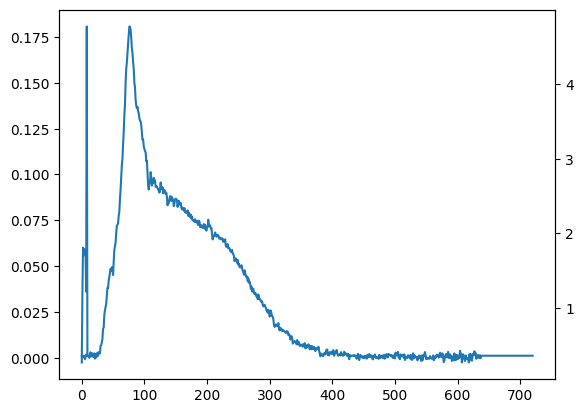

In [29]:
fig, ax = plt.subplots()
ax.plot(E_all[0])
ax2 = ax.twinx()
ax2.plot(reference[0])

## §2.4 Correction vector — `reference / sensor`, per channel, per device
For each measurement, the ratio `reference (LR1-B) / sensor (AS7341)` is computed. 

With `sensor` = `Basic_Counts (§2.1) - Offset ( §2.2)`

The median for each device is then reported in the table 



In [19]:
devices = sorted(df.miniPAR.unique())
ratio = reference / np.maximum(sensor, 1e-12)
factor = {d: np.median(ratio[(df.miniPAR == d).to_numpy()], axis=0) for d in devices}

tbl = pd.DataFrame(factor, index=CH).T
tbl.loc['spread %'] = (tbl.max() - tbl.min()) / tbl.mean() * 100
display(tbl.round(3))

SPECTRAL_COEF = tbl.iloc[:-1,:].mean(axis=0)

F = np.array([factor[d] for d in df.miniPAR])
corrected = F * sensor                                   # workbook F10 = E10*(C10-D10)
reconstructed = corrected @ CM.T                         # (n, 721)
print('reconstructed spectra:', reconstructed.shape)
print("\nAveraged spectral coeficient:")
print(SPECTRAL_COEF)

,f1_415,f2_445,f3_480,f4_515,f5_555,f6_590,f7_630,f8_680,clear,nir
miniPAR_3CDC750C04F4,34.250,64.298,71.202,62.728,55.624,52.354,48.243,41.457,33.441,5.738
miniPAR_3CDC750C0518,34.822,65.751,73.364,63.498,57.495,53.171,48.898,42.865,30.392,5.822
miniPAR_3CDC750C0524,35.780,65.820,73.528,63.594,57.092,53.351,48.979,43.693,30.865,5.785
spread %,4.377,2.331,3.199,1.369,3.297,1.883,1.512,5.239,9.658,1.464


reconstructed spectra: (195, 721)

Averaged spectral coeficient:
f1_415    34.950663
f2_445    65.289484
f3_480    72.697997
f4_515    63.273264
f5_555    56.737110
f6_590    52.958660
f7_630    48.706781
f8_680    42.671670
clear     31.565986
nir        5.781618
dtype: float64


### Apply §2.1, §2.2 and the `Averaged spectral coeficient` for each measurements, then predict par.




In [20]:
# The deployable chain: raw channel counts -> irradiance-like signal, with ONE
# device-independent coefficient vector (no per-device `factor` lookup).
def to_signal(frame):
    """§2.1 basic counts -> §2.2 default offset -> §2.4 averaged spectral coefficient."""
    gt = frame.gain.map(gain_multiplier) * (frame.aint + 1) * (frame.astep + 1) * 2.78e-3   # ms
    b = frame[CH].to_numpy(float) / gt.to_numpy()[:, None]        # §2.1 basic counts
    s = np.clip(b - OFFSET_BASIC, 0.0, None)                      # §2.2 offset removed
    return s * SPECTRAL_COEF.to_numpy()                           # §2.4 averaged coefficient

signal = to_signal(df)                                            # (n, 10)
X = pd.DataFrame(signal, columns=CH, index=df.index)




In [21]:
SPECTRAL_COEF

f1_415    34.950663
f2_445    65.289484
f3_480    72.697997
f4_515    63.273264
f5_555    56.737110
f6_590    52.958660
f7_630    48.706781
f8_680    42.671670
clear     31.565986
nir        5.781618
dtype: float64

In [22]:
# The deployable chain: raw channel counts -> irradiance-like signal, with ONE
# device-independent coefficient vector (no per-device `factor` lookup).
def to_signal(frame):
    """§2.1 basic counts -> §2.2 default offset -> §2.4 averaged spectral coefficient."""
    gt = frame.gain.map(gain_multiplier) * (frame.aint + 1) * (frame.astep + 1) * 2.78e-3   # ms
    b = frame[CH].to_numpy(float) / gt.to_numpy()[:, None]        # §2.1 basic counts
    s = np.clip(b - OFFSET_BASIC, 0.0, None)                      # §2.2 offset removed
    return s * SPECTRAL_COEF.to_numpy()                           # §2.4 averaged coefficient

signal = to_signal(df)                                            # (n, 10)
X = pd.DataFrame(signal, columns=CH, index=df.index)


